### For more information regarding updating feature services, see the following tutorial
https://developers.arcgis.com/python/sample-notebooks/updating-features-in-a-feature-layer/

In [23]:
# Connect to the GIS
from arcgis.gis import GIS
from arcgis import features
import pandas as pd
from arcgis import geometry #use geometry module to project Long,Lat to X and Y
from copy import deepcopy
import arcpy
import datetime
import getpass

arcpy.env.overwriteOutput=True

Enter your password: ········


In [24]:
print("Logging In...")
# Login using my login credentials
username = input('Enter User Name: ')
password = getpass.getpass('Enter your password: ')
gis = GIS("https://www.arcgis.com", username, password)

Logging In...
Enter User Name: cara_moore


In [5]:
# Define service IDs to GET data
washoe_parcel_ID = 'd459154b4687475f8baefda30532f826'
test_ID = '2e879491cb65448781252897334e860e'


Getting the feature service by ID...


<Item title:"Parcels" type:Feature Layer Collection owner:washoe>
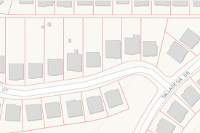

In [20]:
print("Getting the feature service by ID...")
# Get the data
parcel_item = gis.content.get(washoe_parcel_ID)
parcel_item

In [7]:
print("Getting the Parcel layer from the Feature service...")
# Get the parcel layer by referencing the layer number
parcel_feature_layer = parcel_item.layers[0]

Getting the Parcel layer from the Feature service...


In [8]:
parcel_feature_layer

<FeatureLayer url:"https://wcgisweb.washoecounty.us/arcgis/rest/services/OpenData/OpenData/FeatureServer/0">

In [9]:
print("Querying the parcel data")
# Get the parcel data as a pandas dataframe
parcel_feature_layer_qry  = parcel_feature_layer.query().sdf 

Querying the parcel data


In [10]:
parcel_feature_layer_qry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186956 entries, 0 to 186955
Data columns (total 70 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   OBJECTID          186956 non-null  int64   
 1   APN               186956 non-null  int64   
 2   REGION            186499 non-null  object  
 3   PIN               186956 non-null  object  
 4   RECMAP            186521 non-null  object  
 5   BOOK              186956 non-null  object  
 6   PAGE              186956 non-null  object  
 7   BLOCK             186956 non-null  object  
 8   PARCEL            186956 non-null  object  
 9   SUBNAME           186685 non-null  object  
 10  TOWNSHIP          180536 non-null  object  
 11  RANGE             180536 non-null  object  
 12  SECTION_          179652 non-null  object  
 13  FLOOR             186258 non-null  float64 
 14  MAPLINK           186956 non-null  object  
 15  FLR               186258 non-null  float64 
 16  ST

In [27]:
parcel_feature_layer_qry['PIN']

0         001-020-00
1         001-020-01
2         001-020-02
3         001-020-03
4         001-020-04
             ...    
186951    570-282-02
186952    570-282-03
186953    570-282-04
186954    570-282-05
186955    570-282-06
Name: PIN, Length: 186956, dtype: object

## In the future you may want to use street address + APN as a unique identifier in case APN changes

In [28]:
# Create Join Field
parcel_feature_layer_qry['APN_Join'] = parcel_feature_layer_qry['PIN'] # Setup field for joining

## Query Columns to determine if they are the same as last download

In [11]:
# Define list of current columns
df_columns = parcel_feature_layer_qry.columns.tolist()
print(df_columns)

# List of Expected Columns
expected_columns = ['OBJECTID', 'APN', 'REGION', 'PIN', 'RECMAP', 'BOOK', 'PAGE', 'BLOCK', 'PARCEL', 'SUBNAME', 'TOWNSHIP', 'RANGE', 'SECTION_', 'FLOOR', 'MAPLINK', 'FLR', 'STREETNUM', 'STREETDIR', 'STREET', 'CITY', 'SITUSZIP', 'FIRSTNAME', 'LASTNAME', 'MAILING1', 'MAILING2', 'MAILCITY', 'MAILSTATE', 'MAILZIP', 'LAND_USE', 'WATER', 'SEWER', 'ACREAGE', 'TAXDIST', 'BEDROOMS', 'BATHS', 'YEARBLT', 'LANDASS', 'BUILDASS', 'TOTALASS', 'LANDAPR', 'BUILDAPR', 'TOTALAPR', 'DEPRECIATION', 'SALEDATE', 'SALEPRICE', 'OCCUPANCY', 'PROPCODE', 'TAXYEAR', 'STORIES', 'TOWNHOUSE', 'SQFEET', 'UNITS', 'AVCONSYEAR', 'BUILDINGTYPE', 'NBHD', 'SPECPROPCODE', 'QC', 'LAND_BASE', 'NBC', 'Fireplaces', 'Agency', 'AG_ABBR', 'FullAddress', 'ZoningWithDetail', 'HeatType', 'SecHeatType', 'Zoning', 'Zoning_GIS', 'STRAP', 'SHAPE']

# Compare columns and write outcome to text log
date_time_now = datetime.datetime.now()
if df_columns == expected_columns:
    print(str(date_time_now) + ' - SUCCESS - Wahoe Schema is the same - \n')
    f = open('C:\working_folder\Parcel Log.txt', 'a') # open file log in append mode
    f.write(str(date_time_now) + "- SUCCESS - Wahoe Schema is the same - \n") # Write the error with new line
    f.close()
    
else:
    print(str(date_time_now) + ' - FAILED - Washoe Schema Did not Work')
    f = open('C:\working_folder\Parcel Log.txt', 'a') # open file log in append mode
    f.write(str(date_time_now) + " - FAILED - Washoe Schema Did not match.\n") # Write the error with new line
    f.close()

['OBJECTID', 'APN', 'REGION', 'PIN', 'RECMAP', 'BOOK', 'PAGE', 'BLOCK', 'PARCEL', 'SUBNAME', 'TOWNSHIP', 'RANGE', 'SECTION_', 'FLOOR', 'MAPLINK', 'FLR', 'STREETNUM', 'STREETDIR', 'STREET', 'CITY', 'SITUSZIP', 'FIRSTNAME', 'LASTNAME', 'MAILING1', 'MAILING2', 'MAILCITY', 'MAILSTATE', 'MAILZIP', 'LAND_USE', 'WATER', 'SEWER', 'ACREAGE', 'TAXDIST', 'BEDROOMS', 'BATHS', 'YEARBLT', 'LANDASS', 'BUILDASS', 'TOTALASS', 'LANDAPR', 'BUILDAPR', 'TOTALAPR', 'DEPRECIATION', 'SALEDATE', 'SALEPRICE', 'OCCUPANCY', 'PROPCODE', 'TAXYEAR', 'STORIES', 'TOWNHOUSE', 'SQFEET', 'UNITS', 'AVCONSYEAR', 'BUILDINGTYPE', 'NBHD', 'SPECPROPCODE', 'QC', 'LAND_BASE', 'NBC', 'Fireplaces', 'Agency', 'AG_ABBR', 'FullAddress', 'ZoningWithDetail', 'HeatType', 'SecHeatType', 'Zoning', 'Zoning_GIS', 'STRAP', 'SHAPE']
2022-01-20 13:52:54.954009 - SUCCESS - Wahoe Schema is the same - 



# ***Insert TRPA script here to massage data into TRPA format before updating online feature service***
# ...
# ...

# *Example Below to update an online feature service - Working - *
https://developers.arcgis.com/python/sample-notebooks/updating-features-in-a-feature-layer/

It looks like this work even if editing is enable on a feature service. 

### Example parcels subset to work with for now. - this is available in the group TRCD-TRPA Data Share

In [75]:
# Example parcels subset to work with for now. - this is available in the group TRCD-TRPA Data Share
my_parcels = '8f2f6d1517154a76bca355f6e166907e'

Getting the feature service by ID...


<Item title:"Washoe_Parcels_Subset_2021_Example" type:Feature Layer Collection owner:cara_moore>
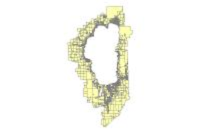

In [76]:
print("Getting the feature service by ID...")
# Get the data
my_parcel_item = gis.content.get(my_parcels)
my_parcel_item

In [77]:
print("Getting the Parcel layer from the Feature service...")
# Get the parcel layer by referencing the layer number
my_parcel_feature_layer = my_parcel_item.layers[0]
my_parcel_feature_layer

Getting the Parcel layer from the Feature service...


<FeatureLayer url:"https://services6.arcgis.com/1KtlSd2mklZMBKaz/arcgis/rest/services/Washoe_Parcels_Subset_2021_Example/FeatureServer/0">

## Query the feature set

In [78]:
print("Querying the dspace feature set...")
my_parcel_feature_set = my_parcel_feature_layer.query()
my_parcel_feature_set

Querying the dspace feature set...


<FeatureSet> 60 features

In [79]:
print("Querying the parcel data")
# Get the parcel data as a pandas dataframe
my_parcel_feature_layer_qry  = my_parcel_feature_layer.query().sdf
my_parcel_feature_layer_qry['APN_Join'] = my_parcel_feature_layer_qry['APN'] # Setup field for joining
my_parcel_feature_layer_qry.info()

Querying the parcel data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   OBJECTID                       60 non-null     int64   
 1   APN                            60 non-null     object  
 2   PPNO                           60 non-null     int64   
 3   HSE_NUMBR                      60 non-null     object  
 4   UNIT_NUMBR                     60 non-null     object  
 5   STR_DIR                        60 non-null     object  
 6   STR_NAME                       60 non-null     object  
 7   STR_SUFFIX                     60 non-null     object  
 8   APO_ADDRESS                    60 non-null     object  
 9   PSTL_TOWN                      60 non-null     object  
 10  PSTL_STATE                     60 non-null     object  
 11  PSTL_ZIP5                      60 non-null     object  
 12  OWN_FIRST    

## Identify Overlapping Rows with a Merge

In [80]:
overlap_rows = pd.merge(left = my_parcel_feature_layer_qry, right = parcel_feature_layer_qry, how='inner',
                       on = ['APN_Join'])
df1 = overlap_rows
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 60 entries, 0 to 59
Columns: 131 entries, OBJECTID_x to SHAPE_y
dtypes: float64(23), int64(13), object(95)
memory usage: 61.9+ KB


### Filter out a dataframe that just contains the Last Name that need to be updated

In [99]:
df_ = overlap_rows[(overlap_rows['OWN_LAST'] != overlap_rows['LASTNAME'])]
df_[['APN_Join','OWN_LAST','LASTNAME']]

,APN_Join,OWN_LAST,LASTNAME
0,122-051-01,TEST,TULLOCH et al
1,122-051-02,TEST,DEMERS
2,122-051-03,TEST,LINDBERG
3,122-051-04,TEST,SOHN FAMILY TRUST
4,122-051-05,TEST,MEEHAN FAMILY TRUST
5,122-051-06,TEST,MIU TRUST
6,122-051-07,TEST,SMITH
7,122-051-08,TEST,FREDERIC LIVING TRUST
8,122-051-09,TEST,TALLAC TRUST
9,122-051-10,TEST,THORP TRUST


In [82]:
# Print out a list of the columns
list1 = df_.columns
print(*list1+"\n")

OBJECTID_x
 APN_x
 PPNO
 HSE_NUMBR
 UNIT_NUMBR
 STR_DIR
 STR_NAME
 STR_SUFFIX
 APO_ADDRESS
 PSTL_TOWN
 PSTL_STATE
 PSTL_ZIP5
 OWN_FIRST
 OWN_LAST
 OWN_FULL
 MAIL_ADD1
 MAIL_ADD2
 MAIL_CITY
 MAIL_STATE
 MAIL_ZIP5
 JURISDICTION
 COUNTY
 OWNERSHIP_TYPE
 COUNTY_LANDUSE_CODE
 COUNTY_LANDUSE_DESCRIPTION
 TRPA_LANDUSE_DESCRIPTION
 REGIONAL_LANDUSE
 IMPERVIOUS_SURFACE_SQFT
 ZONING
 ZONING_DESCRIPTION
 SINGLE_FAMILY_DENSITY
 MULTI_FAMILY_DENSITY
 TOURIST_ACCOMMODATION_DENSITY
 BED_BREAKFAST_DENSITY
 TIME_SHARE_DENSITY
 SOIL_1974
 SOIL_2003
 FIREPD
 WITHIN_TRPA_BNDY
 LITTORAL
 AS_LANDVALUE
 AS_IMPROVALUE
 AS_SUM
 TAX_LANDVALUE
 TAX_IMPROVALUE
 TAX_SUM
 TAX_YEAR
 TOWN_CENTER
 LOCATION_TO_TOWNCENTER
 PARCEL_ACRES
 PARCEL_SQFT
 BMPSTATUS
 TMDL_LANDUSE
 CERTDATE
 CERTREISSUEDATE
 SOURCECERTDATE
 SOURCEREISSUEDATE
 Shape__Area
 Shape__Length
 SHAPE_x
 APN_Join
 OBJECTID_y
 APN_y
 REGION
 PIN
 RECMAP
 BOOK
 PAGE
 BLOCK
 PARCEL
 SUBNAME
 TOWNSHIP
 RANGE
 SECTION_
 FLOOR
 MAPLINK
 FLR
 STREETNUM
 STREET

## Note - Goetz versus Goetz family trust - does Emily's script remove family trust out of the last name?
	OWN_LAST 	LASTNAME
35 	GOETZ 	GOETZ FAMILY TRUST

In [83]:
# Create a List of all features to be updated. 

In [114]:
all_features = my_parcel_feature_set.features

features_for_update = [] #list that will contain corrected features

update_data = df_[['APN_Join','LASTNAME']]
for APN in update_data['APN_Join']:
    # get the matching row from csv
    print(APN)
    matching_row = update_data.where(update_data.APN_Join == APN).dropna()
    print(" Changing Last Name of APN " + matching_row['APN_Join'].values[0] + " to " + matching_row['LASTNAME'].values[0]) 
    
     # get the feature to be updated
    original_feature = [f for f in all_features if f.attributes['APN'] == APN][0]

    feature_to_be_updated = deepcopy(original_feature)
    
     # assign the updated values
    feature_to_be_updated.attributes['OWN_LAST'] = matching_row['LASTNAME'].values[0]
    
     #add this to the list of features to be updated
    features_for_update.append(feature_to_be_updated)
    
    
print("List of properties to update generated.  Update next.")

122-051-01
 Changing Last Name of APN 122-051-01 to TULLOCH et al
122-051-02
 Changing Last Name of APN 122-051-02 to DEMERS
122-051-03
 Changing Last Name of APN 122-051-03 to LINDBERG
122-051-04
 Changing Last Name of APN 122-051-04 to SOHN FAMILY TRUST
122-051-05
 Changing Last Name of APN 122-051-05 to MEEHAN FAMILY TRUST
122-051-06
 Changing Last Name of APN 122-051-06 to MIU TRUST
122-051-07
 Changing Last Name of APN 122-051-07 to SMITH
122-051-08
 Changing Last Name of APN 122-051-08 to FREDERIC LIVING TRUST
122-051-09
 Changing Last Name of APN 122-051-09 to TALLAC TRUST
122-051-10
 Changing Last Name of APN 122-051-10 to THORP TRUST
122-052-02
 Changing Last Name of APN 122-052-02 to BURDETTE
122-052-03
 Changing Last Name of APN 122-052-03 to MICHAEL MOREY & LYNNE KREUZ TRUST
122-052-04
 Changing Last Name of APN 122-052-04 to UNITED STATES OF AMERICA
122-052-05
 Changing Last Name of APN 122-052-05 to JAGO FAMILY TRUST
122-052-06
 Changing Last Name of APN 122-052-06 to HAW

In [109]:
features_for_update

[{"geometry": {"rings": [[[761218.519537017, 4349281.82691538], [761203.261539528, 4349267.61521772], [761188.283841995, 4349253.10862011], [761181.20584316, 4349245.14752142], [761174.571844252, 4349236.81272279], [761168.401645267, 4349228.12902422], [761162.713546203, 4349219.1221257], [761140.825049807, 4349268.64251755], [761149.458248386, 4349274.02071667], [761158.480746901, 4349278.71661589], [761167.83884536, 4349282.70191524], [761177.476743774, 4349285.9528147], [761187.336742151, 4349288.45011429], [761197.3601405, 4349290.17881401], [761215.042737589, 4349292.34751365], [761216.016237428, 4349292.15731368], [761216.946037276, 4349291.81171374], [761217.807437134, 4349291.31991382], [761218.577737007, 4349290.69501392], [761219.236336899, 4349289.95341404], [761219.766236811, 4349289.11491418], [761220.153036748, 4349288.20151433], [761220.386636709, 4349287.23751449], [761220.460836697, 4349286.24841465], [761220.373636711, 4349285.26031482], [761220.127436752, 4349284.299

In [110]:
my_parcel_feature_layer.edit_features(updates= features_for_update)

{'addResults': [],
 'updateResults': [{'objectId': 1,
   'uniqueId': 1,
   'globalId': None,
   'success': True},
  {'objectId': 2, 'uniqueId': 2, 'globalId': None, 'success': True},
  {'objectId': 3, 'uniqueId': 3, 'globalId': None, 'success': True},
  {'objectId': 4, 'uniqueId': 4, 'globalId': None, 'success': True},
  {'objectId': 5, 'uniqueId': 5, 'globalId': None, 'success': True},
  {'objectId': 6, 'uniqueId': 6, 'globalId': None, 'success': True},
  {'objectId': 7, 'uniqueId': 7, 'globalId': None, 'success': True},
  {'objectId': 8, 'uniqueId': 8, 'globalId': None, 'success': True},
  {'objectId': 9, 'uniqueId': 9, 'globalId': None, 'success': True},
  {'objectId': 10, 'uniqueId': 10, 'globalId': None, 'success': True},
  {'objectId': 11, 'uniqueId': 11, 'globalId': None, 'success': True},
  {'objectId': 12, 'uniqueId': 12, 'globalId': None, 'success': True},
  {'objectId': 13, 'uniqueId': 13, 'globalId': None, 'success': True},
  {'objectId': 14, 'uniqueId': 14, 'globalId': Non

### Thoughts - Sometimes APNs change - a new unique ID could be to concatenate APN + Street Number